**Part1 : Data processing Pipeline**

In [55]:
#load dataset and librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

df = pd.read_csv("https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv")

df.info()
# df.shape
df.describe()
# df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


Data Cleaning

In [ ]:
# Here we began data cleaning for the numerical columns

df_clean = df.copy()
df_clean['Runtime'] = pd.to_numeric(df_clean['Runtime'].str.replace(
    'min', '', regex=False,
), errors='coerce')

df_clean['Gross'] = pd.to_numeric(
    df_clean['Gross'].str.replace(',', '', regex=False),
    errors='coerce'
)

df_clean['Released_Year'] = pd.to_numeric(
    df_clean['Released_Year'],
    errors= 'coerce'
)

df_clean = df_clean.drop('Poster_Link', axis = 1)
df_clean.info()
df_clean.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  999 non-null    float64
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   IMDB_Rating    1000 non-null   float64
 6   Overview       1000 non-null   object 
 7   Meta_score     843 non-null    float64
 8   Director       1000 non-null   object 
 9   Star1          1000 non-null   object 
 10  Star2          1000 non-null   object 
 11  Star3          1000 non-null   object 
 12  Star4          1000 non-null   object 
 13  No_of_Votes    1000 non-null   int64  
 14  Gross          831 non-null    float64
dtypes: float64(4), int64(2), object(9)
memory usage: 117.3+ KB


,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,999.000000,1000.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,1991.217217,122.891000,7.949300,77.971530,2.736929e+05,6.803475e+07
std,23.297025,28.093671,0.275491,12.376099,3.273727e+05,1.097500e+08
min,1920.000000,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.000000,103.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,1999.000000,119.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,2009.000000,137.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,2020.000000,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


C:\Users\Mihai\AppData\Local\Temp\ipykernel_37736\2965714679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y='Missing %', data=missing, palette='Reds_r')


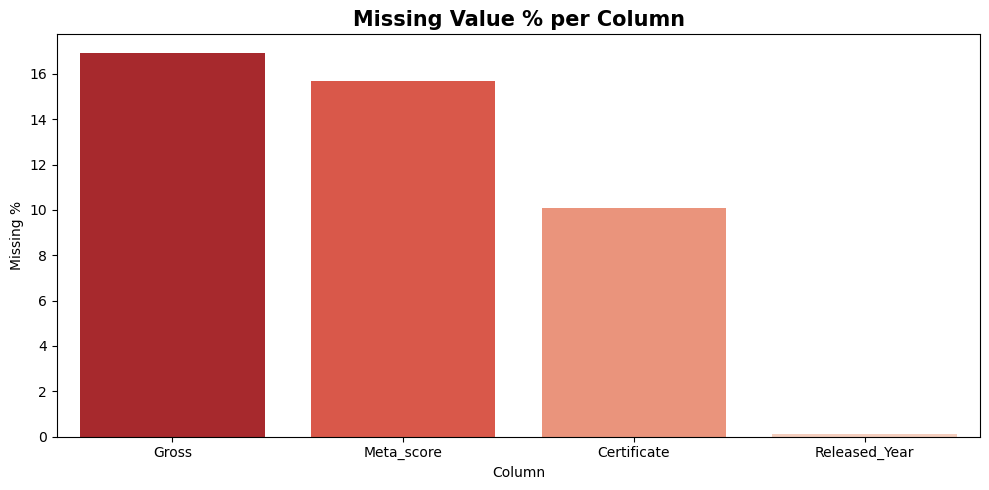

In [57]:
# A quick analysis over missing values

missing = pd.DataFrame({
    "Missing_Count" : df_clean.isnull().sum(),
    "Missing %":(df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).sort_values("Missing %", ascending=False)

missing = missing[missing['Missing_Count'] > 0]
# missing

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y='Missing %', data=missing, palette='Reds_r')
plt.title('Missing Value % per Column', fontsize=15, fontweight='bold')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [ ]:
# Here we will use 2 separate strategies for handling missing data
# one used for numerical data(we use median)
# the other one for categorical data(We fill with unknown)
# another strategy would be to simply remove the rows that have incomplete
# data but as it is we only have 1000 elements so that would not be best

df_clean['Meta_score'] = df_clean['Meta_score'].fillna(df_clean['Meta_score'].median())
df_clean['Gross'] = df_clean['Gross'].fillna(df_clean['Gross'].median())
df_clean['Runtime'] = df_clean['Runtime'].fillna(df_clean['Runtime'].median())


df_clean['Certificate'] = df_clean['Certificate'].fillna('Unknown')
df_clean.dropna(subset=['Released_Year'], inplace=True)
df_clean['Released_Year'] = df_clean['Released_Year'].astype(int)


df_clean.info()
df_clean.describe()
# df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   999 non-null    object 
 1   Released_Year  999 non-null    int64  
 2   Certificate    999 non-null    object 
 3   Runtime        999 non-null    int64  
 4   Genre          999 non-null    object 
 5   IMDB_Rating    999 non-null    float64
 6   Overview       999 non-null    object 
 7   Meta_score     999 non-null    float64
 8   Director       999 non-null    object 
 9   Star1          999 non-null    object 
 10  Star2          999 non-null    object 
 11  Star3          999 non-null    object 
 12  Star4          999 non-null    object 
 13  No_of_Votes    999 non-null    int64  
 14  Gross          999 non-null    float64
dtypes: float64(3), int64(3), object(9)
memory usage: 124.9+ KB


,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,999.000000,999.000000,999.000000,999.000000,9.990000e+02,9.990000e+02
mean,1991.217217,122.873874,7.949650,78.134134,2.736974e+05,6.040016e+07
std,23.297025,28.102520,0.275407,11.373863,3.275366e+05,1.014065e+08
min,1920.000000,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.000000,103.000000,7.700000,72.000000,5.547150e+04,5.011838e+06
50%,1999.000000,119.000000,7.900000,79.000000,1.383560e+05,2.353089e+07
75%,2009.000000,137.000000,8.100000,85.500000,3.744775e+05,6.139004e+07
max,2020.000000,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


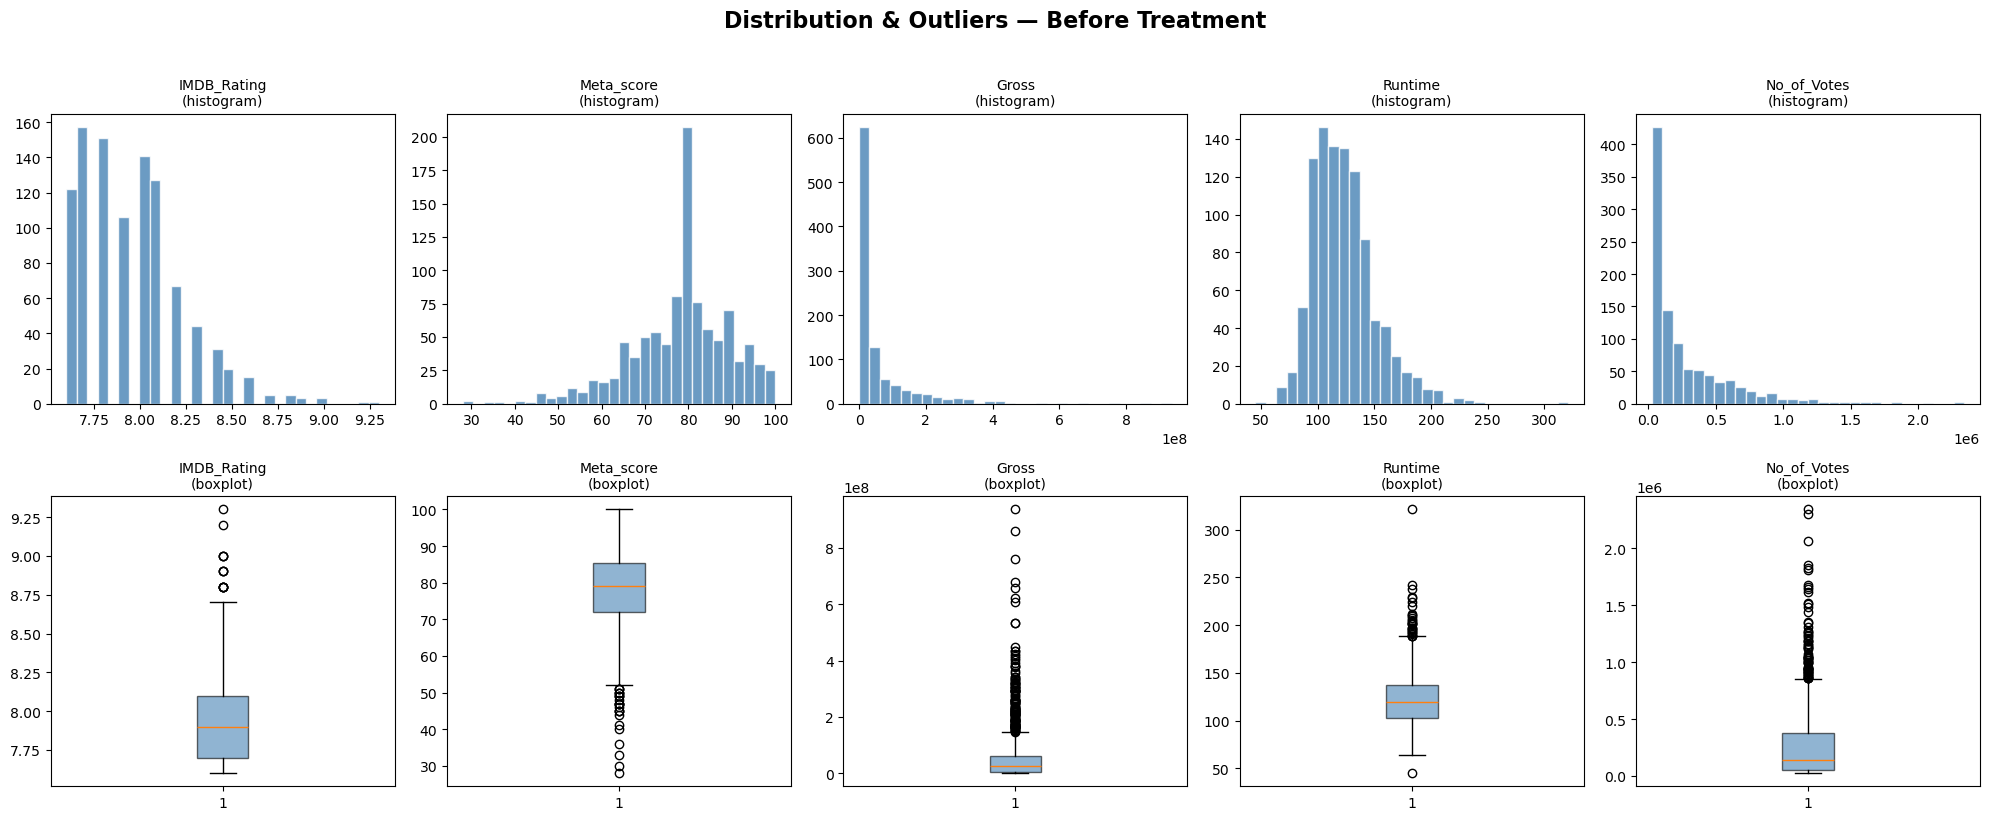

In [59]:
# Visualization of the distribution and possinle outliers for the
# numerical data
numerical_cols = ['IMDB_Rating', 'Meta_score', 'Gross', 'Runtime', 'No_of_Votes']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribution & Outliers — Before Treatment', 
             fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(numerical_cols):
    axes[0, i].hist(df_clean[col].dropna(), bins=30, 
                    color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(histogram)', fontsize=10)
    axes[0, i].set_xlabel('')

    axes[1, i].boxplot(df_clean[col].dropna(), 
                       patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'{col}\n(boxplot)', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Here we made use of a function to check for each numerical column 
# What the outliers looked like and I considered since these data is 
# extracted from IMDB and it is official data , removing data would 
# only remove one or more of the best 1000 films ever.

# I checked for most of the outliers if they exist(I mean movies with that data)
# and they are real. So I decided not to remove outliers

def iqr_outlier_report(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}")
    print(f"Q1={Q1}  Q3={Q3}  IQR={IQR}")
    print(f"Bounds: [{lower}  →  {upper}]")
    print(f"Outliers found: {len(outliers)} ({len(outliers)/len(df)*100}%)")
    if len(outliers) > 0:
        print(f"Min outlier: {df[col].min()}")
        print(f"Max outlier: {df[col].max()}")
    return lower, upper, outliers

bounds = {}
for col in numerical_cols:
    lower, upper, outliers = iqr_outlier_report(df_clean, col)
    bounds[col] = (lower, upper)


IMDB_Rating
Q1=7.7  Q3=8.1  IQR=0.39999999999999947
Bounds: [7.100000000000001  →  8.7]
Outliers found: 13 (1.3013013013013013%)
Min outlier: 7.6
Max outlier: 9.3

Meta_score
Q1=72.0  Q3=85.5  IQR=13.5
Bounds: [51.75  →  105.75]
Outliers found: 25 (2.5025025025025025%)
Min outlier: 28.0
Max outlier: 100.0

Gross
Q1=5011838.5  Q3=61390045.0  IQR=56378206.5
Bounds: [-79555471.25  →  145957354.75]
Outliers found: 124 (12.412412412412413%)
Min outlier: 1305.0
Max outlier: 936662225.0

Runtime
Q1=103.0  Q3=137.0  IQR=34.0
Bounds: [52.0  →  188.0]
Outliers found: 29 (2.902902902902903%)
Min outlier: 45
Max outlier: 321

No_of_Votes
Q1=55471.5  Q3=374477.5  IQR=319006.0
Bounds: [-423037.5  →  852986.5]
Outliers found: 67 (6.706706706706707%)
Min outlier: 25088
Max outlier: 2343110


In [66]:
categorical_cols = ['Certificate', 'Genre', 'Director',
                    'Star1', 'Star2', 'Star3', 'Star4']

for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    print(f"\n{'='*50}")
    print(f"{col} — {len(unique_vals)} unique values:")
    if len(unique_vals) > 30:
        print(f"   (too many to list — showing sample of 10)")
        print(sorted([str(v) for v in unique_vals])[:10])
    else:
        print(sorted([str(v) for v in unique_vals]))


Certificate — 17 unique values:
['16', 'A', 'Approved', 'G', 'GP', 'PG', 'PG-13', 'Passed', 'R', 'TV-14', 'TV-MA', 'TV-PG', 'U', 'U/A', 'UA', 'Unknown', 'Unrated']

Genre — 202 unique values:
   (too many to list — showing sample of 10)
['Action, Adventure', 'Action, Adventure, Biography', 'Action, Adventure, Comedy', 'Action, Adventure, Crime', 'Action, Adventure, Drama', 'Action, Adventure, Family', 'Action, Adventure, Fantasy', 'Action, Adventure, History', 'Action, Adventure, Horror', 'Action, Adventure, Mystery']

Director — 548 unique values:
   (too many to list — showing sample of 10)
['\x1aagan Irmak', '\x1amer Faruk Sorak', 'Aamir Khan', 'Aaron Sorkin', 'Abdellatif Kechiche', 'Abhishek Chaubey', 'Abhishek Kapoor', 'Adam Elliot', 'Adam McKay', 'Aditya Chopra']

Star1 — 660 unique values:
   (too many to list — showing sample of 10)
['\x1aetin Tekindor', '\x1amer Faruk Sorak', '\x1aric Toledano', 'Aamir Khan', 'Aaron Taylor-Johnson', 'Abhay Deol', 'Abraham Attah', 'Adam Driver

In [67]:
director_counts = df_clean['Director'].value_counts()

print("Director appearance distribution:")
print(f"  Directors appearing once:  {(director_counts == 1).sum()}")
print(f"  Directors appearing twice: {(director_counts == 2).sum()}")
print(f"  Directors appearing 3+:    {(director_counts >= 3).sum()}")
print(f"\nTop 10 most frequent directors:")
print(director_counts.head(10))

Director appearance distribution:
  Directors appearing once:  352
  Directors appearing twice: 99
  Directors appearing 3+:    97

Top 10 most frequent directors:
Director
Alfred Hitchcock     14
Steven Spielberg     13
Hayao Miyazaki       11
Akira Kurosawa       10
Martin Scorsese      10
Woody Allen           9
Stanley Kubrick       9
Billy Wilder          9
Clint Eastwood        8
Christopher Nolan     8
Name: count, dtype: int64


Data transformation

Data reduction

Feature engineering

**Part2 : Extracting& Visualizing Insights**

**Part3: Movie recomandation System**